# 4. 데이터 관계의 수학적 표현

- 01부터 03까지의 과정을 통해 각 입력 변수가 결과 변수와 서로 다른 강도와 방향의 관계를 맺고 있음을 확인하였음
- 그러나, 개별적인 상관 관계 분석만으로는 모든 특성을 종합적으로 고려한 최종 점수를 예측하는 결론을 내기에는 어려움이 있음.
- 모델링은 복잡하고 다차원적인 관계를 `하나의 일관된 수학적 규칙으로 정립`하는 과정
    1. 각 특성의 상대적 중요도(가중치)를 객관적으로 산출
    2. 새로운 데이터에 대한 예측을 수행할 수 있는 일반화된 시스템 구축이 최종 목표

## 4-1. 선형 모델, 가중치, 편향

### 4-1-1. 선형 모델(Linear Model)

- 하나 이상의 입력 변수(X)와 결과 변수(Y) 사이에 `직선 관계`가 있다고 가정. 이를 $Y = WX + b$ 형태의 수학 방정식으로 표현하는 모델
- 머신 러닝에서 가장 기본적이고 해석이 용이한 모델 중 하나

### 4-1-2. 가중치와 편향

1. **가중치(Weight, W)**
    - 각 입력 변수가 결과 변수에 미치는 **영향력 또는 중요도**를 나타내는 게수
    - 가중치의 절대값이 클수록 해당 특성이 예측에 더 큰 영향을 미침
2. **편향(Bias, b)**
    - 모든 입력 변수가 0일 때의 **기본 예측값**
    - 모델이 데이터 전체의 기본적인 편향을 학습할 수 있도록 돕는 절편(intercept) 역할

In [1]:
# Google Drive 연결
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/Colab Notebooks/'

ModuleNotFoundError: No module named 'google.colab'

In [3]:
import pandas as pd
import matplotlib.pyplot as plt

# 실습에 사용할 메인 데이터셋 로드
df_main = pd.read_csv('virtual_student_data.csv')
# df_main = pd.read_csv(base_path + 'virtual_student_data.csv')

# 메인 데이터셋 정보 확인
print("Main Dataset Info:")
df_main.info()

Main Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       200 non-null    int64  
 1   final_score      200 non-null    float64
 2   assignment_rate  200 non-null    float64
 3   sub_rate_d1      200 non-null    float64
 4   sub_rate_d2      200 non-null    float64
 5   sub_rate_d3      200 non-null    float64
 6   sub_rate_d4      200 non-null    float64
 7   sub_rate_d5      200 non-null    float64
 8   sub_rate_d6      200 non-null    float64
 9   sub_rate_d7      200 non-null    float64
 10  sub_rate_d8      200 non-null    float64
dtypes: float64(10), int64(1)
memory usage: 17.3 KB


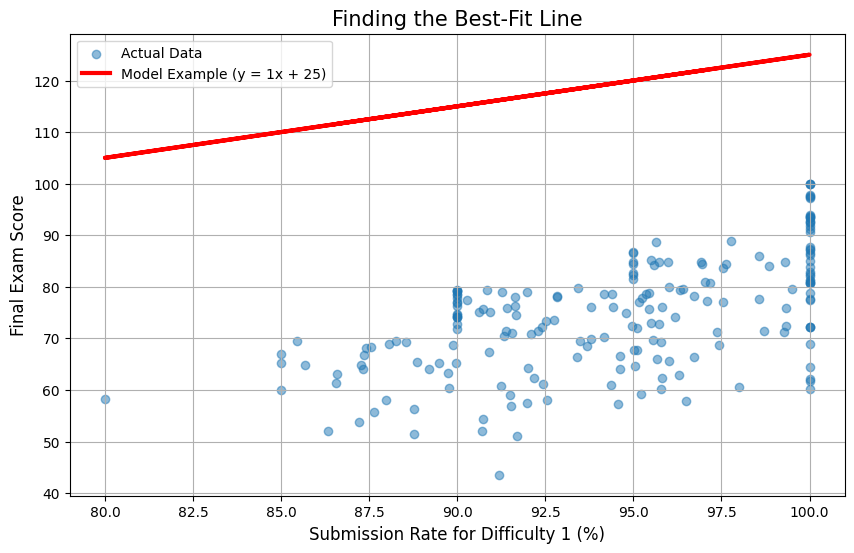

In [4]:
import numpy as np
# 1. 가장 상관관계가 높았던 특성과 결과 변수 선택
sub_rate_d1 = df_main['sub_rate_d1']
final_score = df_main['final_score']

plt.figure(figsize=(10, 6))
plt.scatter(sub_rate_d1, final_score, alpha=0.5, label='Actual Data')
plt.title('Finding the Best-Fit Line', fontsize=15)
plt.xlabel('Submission Rate for Difficulty 1 (%)', fontsize=12)
plt.ylabel('Final Exam Score', fontsize=12)
plt.grid(True)

# 3. 임의의 직선(모델) 그려보기
# 가중치와 편향을 변경해 보며 최적의 직선을 찾아보자.
W_example = 1  # 가상의 가중치 (기울기)
b_example = 25   # 가상의 편향 (y절편)

# 특성
x_line = np.array(sub_rate_d1) 
# 모델에 의한 예측값
y_line = W_example * x_line + b_example
# label은 legend에 표시될 문자열
plt.plot(x_line, y_line, color='red', linewidth=3, label=f'Model Example (y = {W_example}x + {b_example})')
plt.legend()
plt.show()